# Titanic ML end-to-end (scikit-learn)
In questo notebook carichiamo il dataset Titanic, facciamo preprocessing completo e alleniamo una Logistic Regression per classificare `survived` (0 = non sopravvissuto, 1 = sopravvissuto).

In [1]:
import seaborn as sns

# Load the built-in titanic dataset
df = sns.load_dataset('titanic')

# Display the first 5 rows
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


## 1) Ripulire il dataset
Obiettivo: tenere le colonne utili al modello, gestire i valori mancanti e verificare il risultato con un grafico dei missing values prima/dopo.

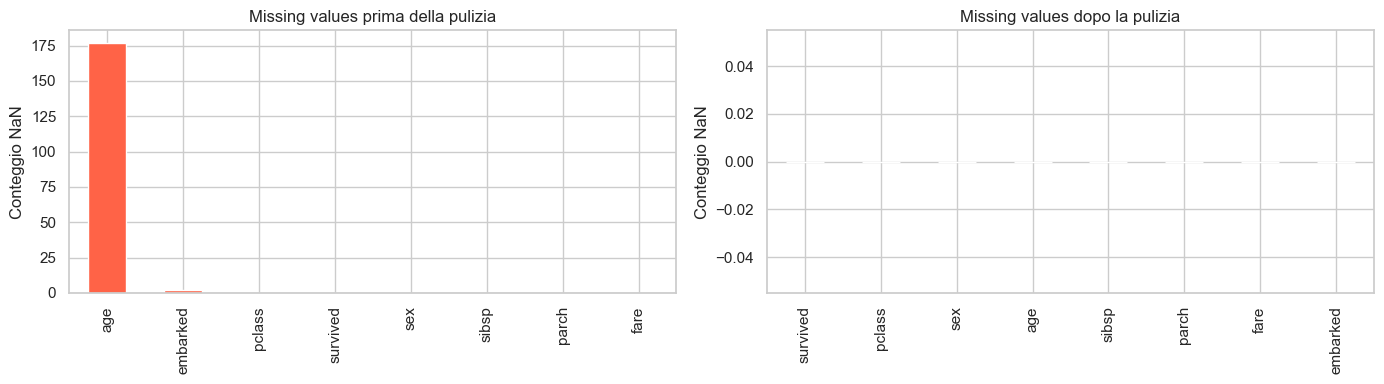

Shape dopo pulizia: (780, 8)
Missing values residui:
 survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

selected_cols = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
df_clean = df[selected_cols].copy()

missing_before = df_clean.isna().sum()

df_clean = df_clean.drop_duplicates()
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
df_clean['fare'] = df_clean['fare'].fillna(df_clean['fare'].median())
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])

missing_after = df_clean.isna().sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
missing_before.sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='tomato')
axes[0].set_title('Missing values prima della pulizia')
axes[0].set_ylabel('Conteggio NaN')

missing_after.sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Missing values dopo la pulizia')
axes[1].set_ylabel('Conteggio NaN')

plt.tight_layout()
plt.show()

print('Shape dopo pulizia:', df_clean.shape)
print('Missing values residui:\n', missing_after)
df_clean.head()

## 2) Convertire categorie in numeri
Obiettivo: trasformare le variabili categoriche (`sex`, `embarked`) in variabili numeriche usando one-hot encoding, cosÃƒÆ’Ã‚Â¬ il modello puÃƒÆ’Ã‚Â² usarle.

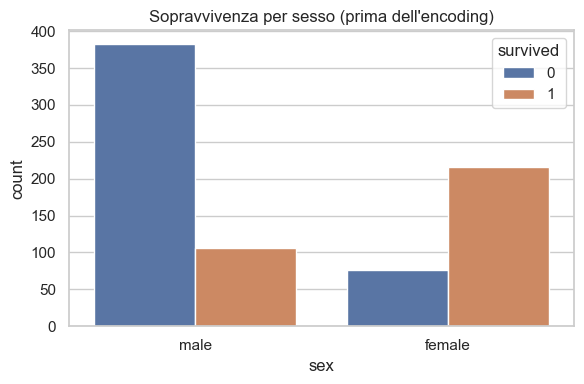

Colonne dopo encoding:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']


,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='sex', hue='survived')
plt.title('Sopravvivenza per sesso (prima dell\'encoding)')
plt.tight_layout()
plt.show()

df_encoded = pd.get_dummies(df_clean, columns=['sex', 'embarked'], drop_first=True, dtype=int)

print('Colonne dopo encoding:')
print(df_encoded.columns.tolist())
df_encoded.head()

Il grafico mostra che il sesso ha un impatto forte sulla sopravvivenza; questa informazione, dopo encoding, viene passata al modello in forma numerica.

## 3) Rimuovere outlier con z-score 3
Obiettivo: identificare valori estremi sulle variabili numeriche principali e rimuovere le righe con `|z| >= 3`.

Righe prima: 780
Righe dopo rimozione outlier: 717
Outlier rimossi: 63


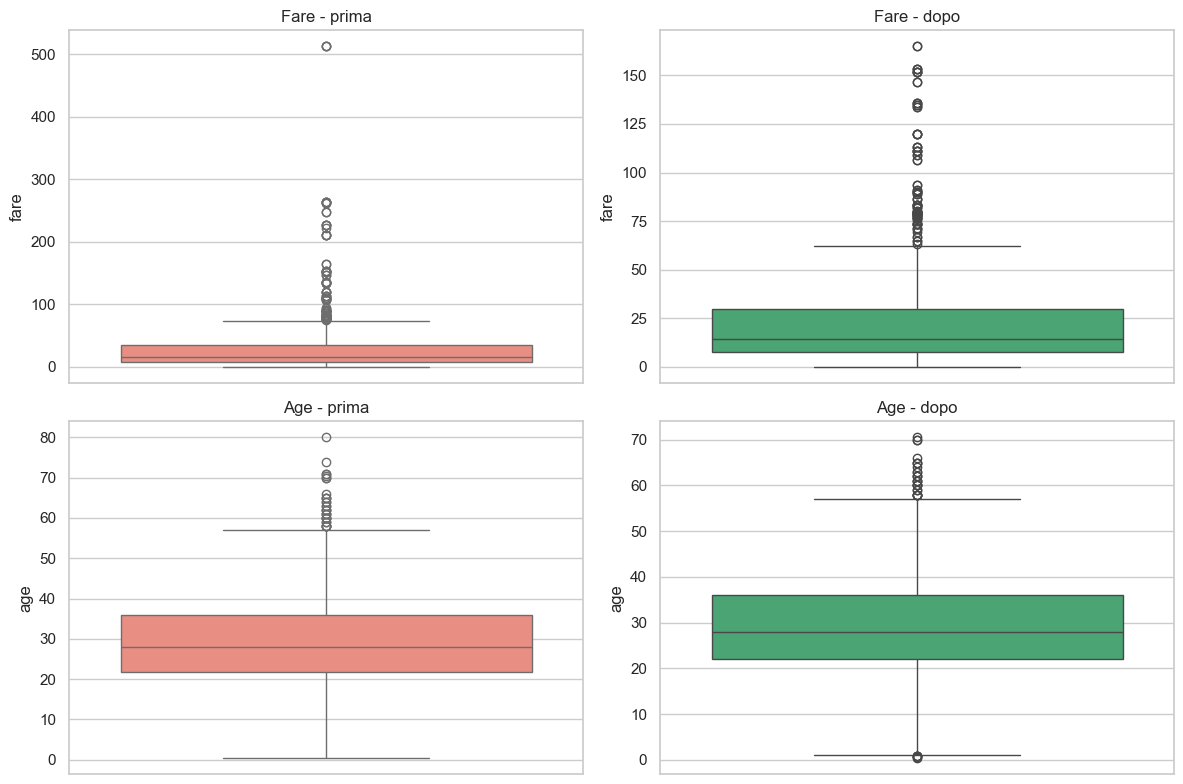

In [5]:
from scipy.stats import zscore

numeric_outlier_cols = ['age', 'fare', 'sibsp', 'parch']
z_scores = np.abs(zscore(df_encoded[numeric_outlier_cols]))
mask = (z_scores < 3).all(axis=1)
df_no_outliers = df_encoded[mask].copy()

print(f'Righe prima: {len(df_encoded)}')
print(f'Righe dopo rimozione outlier: {len(df_no_outliers)}')
print(f'Outlier rimossi: {len(df_encoded) - len(df_no_outliers)}')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(y=df_encoded['fare'], ax=axes[0, 0], color='salmon')
axes[0, 0].set_title('Fare - prima')
sns.boxplot(y=df_no_outliers['fare'], ax=axes[0, 1], color='mediumseagreen')
axes[0, 1].set_title('Fare - dopo')
sns.boxplot(y=df_encoded['age'], ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Age - prima')
sns.boxplot(y=df_no_outliers['age'], ax=axes[1, 1], color='mediumseagreen')
axes[1, 1].set_title('Age - dopo')
plt.tight_layout()
plt.show()

I boxplot confrontano prima/dopo: dopo il filtro z-score le code estreme sono ridotte, con dati piu stabili per il training.

## 4) Feature engineering
Obiettivo: creare nuove feature utili al modello, ad esempio dimensione famiglia e costo medio per persona.

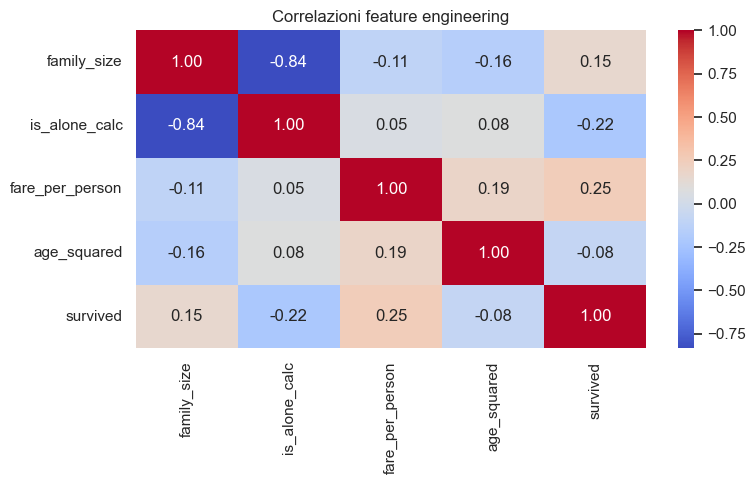

,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S,family_size,is_alone_calc,fare_per_person,age_squared
0,0,3,22.0,1,0,7.2500,1,0,1,2,0,3.62500,484.0
1,1,1,38.0,1,0,71.2833,0,0,0,2,0,35.64165,1444.0
2,1,3,26.0,0,0,7.9250,0,0,1,1,1,7.92500,676.0
3,1,1,35.0,1,0,53.1000,0,0,1,2,0,26.55000,1225.0
4,0,3,35.0,0,0,8.0500,1,0,1,1,1,8.05000,1225.0


In [6]:
df_fe = df_no_outliers.copy()

df_fe['family_size'] = df_fe['sibsp'] + df_fe['parch'] + 1
df_fe['is_alone_calc'] = (df_fe['family_size'] == 1).astype(int)
df_fe['fare_per_person'] = df_fe['fare'] / df_fe['family_size']
df_fe['age_squared'] = df_fe['age'] ** 2

engineered_cols = ['family_size', 'is_alone_calc', 'fare_per_person', 'age_squared', 'survived']
corr = df_fe[engineered_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlazioni feature engineering')
plt.tight_layout()
plt.show()

df_fe.head()

La heatmap aiuta a capire se le nuove feature hanno segnale rispetto a `survived` e rispetto alle altre variabili.

## 5) Normalizzare verso una distribuzione piu gaussiana (trasformazione logaritmica)
Obiettivo: ridurre la skewness delle feature numeriche con una trasformazione logaritmica (`log1p`) per rendere le distribuzioni piu simili a una gaussiana.

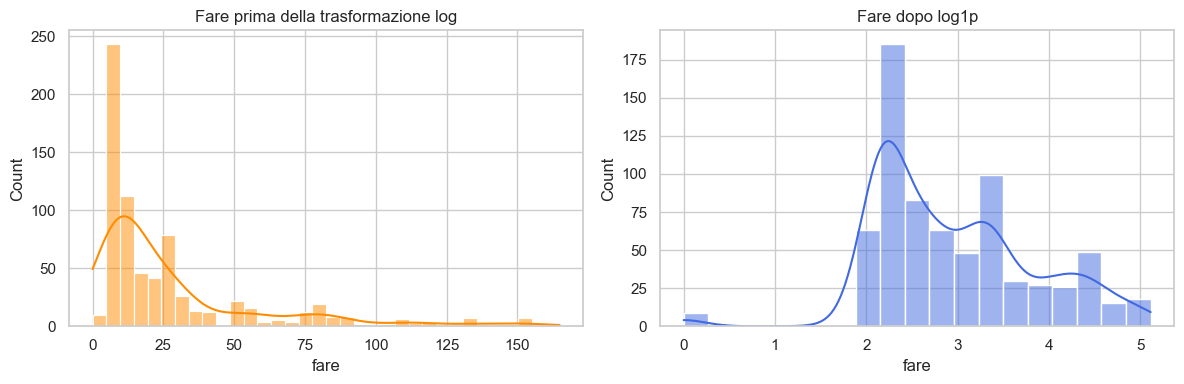

Feature con log1p applicata: ['fare_per_person', 'fare', 'parch', 'sibsp', 'age_squared', 'family_size']

Skewness prima (top 5):
 fare_per_person    3.191973
fare               2.142501
parch              1.929734
sibsp              1.807023
age_squared        1.654583
dtype: float64

Skewness dopo (top 5):
 parch              1.648751
sibsp              1.138871
family_size        1.011014
fare_per_person    0.403896
age                0.400098
dtype: float64
Shape train: (573, 12)
Shape test: (144, 12)


In [9]:
from sklearn.model_selection import train_test_split

X = df_fe.drop(columns='survived')
y = df_fe['survived']

numeric_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'fare_per_person', 'age_squared']

skew_before = X[numeric_cols].skew().sort_values(ascending=False)
skewed_cols = skew_before[skew_before.abs() > 0.75].index.tolist()

X_log = X.copy()
for col in skewed_cols:
    X_log[col] = np.log1p(X_log[col])

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_log, y, test_size=0.2, random_state=42, stratify=y
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(X['fare'], kde=True, ax=axes[0], color='darkorange')
axes[0].set_title('Fare prima della trasformazione log')
sns.histplot(X_log['fare'], kde=True, ax=axes[1], color='royalblue')
axes[1].set_title('Fare dopo log1p')
plt.tight_layout()
plt.show()

skew_after = X_log[numeric_cols].skew().sort_values(ascending=False)
print('Feature con log1p applicata:', skewed_cols)
print('\nSkewness prima (top 5):\n', skew_before.head())
print('\nSkewness dopo (top 5):\n', skew_after.head())

print('Shape train:', X_train_scaled.shape)
print('Shape test:', X_test_scaled.shape)

La trasformazione logaritmica riduce l'asimmetria delle feature piu skewed, rendendo la distribuzione piu vicina a una gaussiana e piu adatta al training del classificatore.

## 6) Logistic Regression per classificare i sopravvissuti
Obiettivo: addestrare un classificatore binario su `survived`, misurare metriche di classificazione e visualizzare i risultati con matrici e curve.

Accuracy : 0.708
Precision: 0.641
Recall   : 0.683
F1-score : 0.661
ROC AUC  : 0.781

Classification report:

              precision    recall  f1-score   support

           0       0.76      0.73      0.74        84
           1       0.64      0.68      0.66        60

    accuracy                           0.71       144
   macro avg       0.70      0.70      0.70       144
weighted avg       0.71      0.71      0.71       144



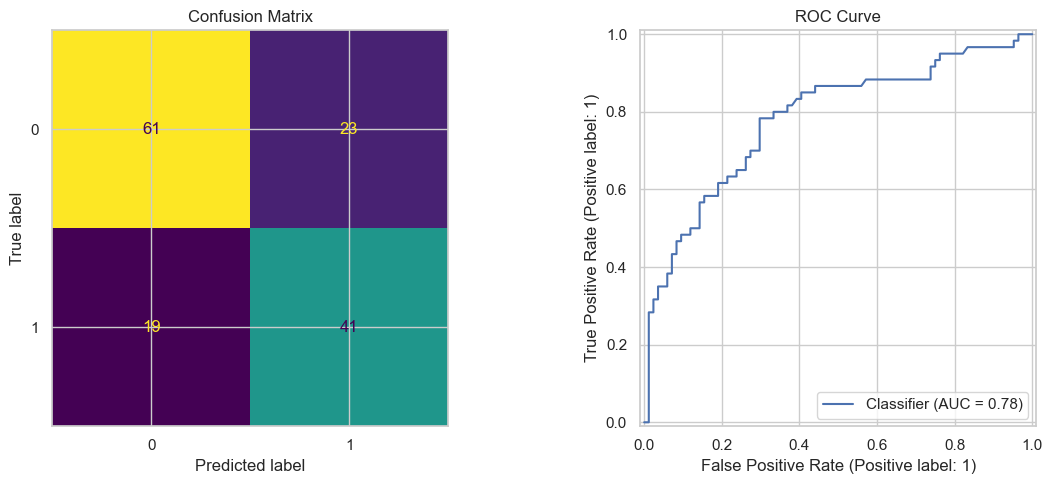

C:\Users\ilari\AppData\Local\Temp\ipykernel_37688\3141370528.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_coef.values, y=top_coef.index, palette='vlag')


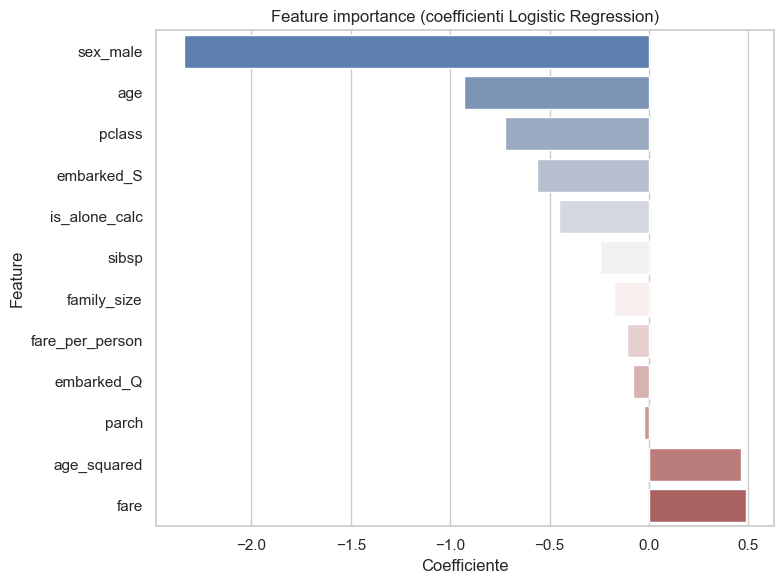

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)

model = LogisticRegression(max_iter=2000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f'Accuracy : {acc:.3f}')
print(f'Precision: {prec:.3f}')
print(f'Recall   : {rec:.3f}')
print(f'F1-score : {f1:.3f}')
print(f'ROC AUC  : {auc:.3f}\n')
print('Classification report:\n')
print(classification_report(y_test, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title('ROC Curve')
plt.tight_layout()
plt.show()

coef_series = pd.Series(model.coef_[0], index=X_train_scaled.columns).sort_values()
top_coef = pd.concat([coef_series.head(8), coef_series.tail(8)])

plt.figure(figsize=(8, 6))
sns.barplot(x=top_coef.values, y=top_coef.index, palette='vlag')
plt.title('Feature importance (coefficienti Logistic Regression)')
plt.xlabel('Coefficiente')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Interpretazione rapida:
- La confusion matrix mostra il bilanciamento tra veri/falsi positivi e negativi.
- La ROC curve mostra la capacita discriminante del modello (`AUC` piu alto e meglio).
- Il grafico dei coefficienti indica quali feature spingono la probabilita di sopravvivenza verso 1 o verso 0.